In [1]:
pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 1.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Bộ Môn/Giảng Dạy/2025-2026/NMMH/lab04/Customer_Behaviour.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## Data Analysis

In [5]:
# Get categorical columns and numerical columns
categorical_cols = [feature for feature in df.columns if df[feature].dtype == "O"]
numerical_cols = [feature for feature in df.columns if df[feature].dtype != "O"]

In [6]:
numerical_cols

['User ID', 'Age', 'EstimatedSalary', 'Purchased']

In [7]:
from ydata_profiling import ProfileReport

/tmp/ipykernel_3685/44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [8]:
ProfileReport(df, title="Report")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 191.75it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## Preprocessing

In [10]:
def preprocessing_data(df):
    """
    Preprocess your data (eg. Drop null datapoints or fill missing data)
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    df.drop("User ID", axis=1, inplace=True)
    return df

In [11]:
df = preprocessing_data(df)
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


## Feature Engineering

In [27]:
# Heatmap
import seaborn as sns

def apply_feature_engineering(df):
    """
    Apply all feature engineering to transform your data into number
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    df["Gender"] = df["Gender"].astype("category").cat.codes
    return df

df = apply_feature_engineering(df)

In [28]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0


##Model Training

In [29]:
def prepare_X_y(df):
    """
    Feature engineering and create X and y
    :param df: pandas dataframe
    :return: (X, y) output feature matrix (dataframe), target (series)
    """
    feature_names = df.columns.tolist()
    feature_names.remove("Purchased")

    X = df[feature_names].values
    y = df.Purchased.values
    return X, y

X, y = prepare_X_y(df)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [31]:
# -- Build a full pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

clf = DecisionTreeClassifier()
pipe = Pipeline(steps=[("tree", clf)]) #Build a pipeline with a scaler and a model

# Parameters of pipelines can be set using '__' separated parameter names:
param_grid = {
    'tree__criterion': ["gini", "entropy"]
    }

search = GridSearchCV(pipe, param_grid, scoring="recall", n_jobs=2)
search.fit(X_train, y_train)
print("Best parameter (CV score=%0.3f):" % search.best_score_)
print(search.best_params_)

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
predicted_label = search.predict(X_test)
print(classification_report(y_test, predicted_label))

Best parameter (CV score=0.765):
{'tree__criterion': 'gini'}
              precision    recall  f1-score   support

           0       0.82      0.83      0.82        48
           1       0.74      0.72      0.73        32

    accuracy                           0.79        80
   macro avg       0.78      0.78      0.78        80
weighted avg       0.79      0.79      0.79        80



## Upsampling

In [33]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(k_neighbors=5, random_state=0)
X_train_oversampling, y_train_oversampling = smote.fit_resample(X_train, y_train)

In [34]:
# -- Build a full pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

clf = DecisionTreeClassifier()
pipe = Pipeline(steps=[("tree", clf)]) #Build a pipeline with a scaler and a model

# Parameters of pipelines can be set using '__' separated parameter names:
param_grid = {
    'tree__criterion': ["gini", "entropy"]
    }

search = GridSearchCV(pipe, param_grid, scoring="recall", n_jobs=2)
search.fit(X_train_oversampling, y_train_oversampling)
print("Best parameter (CV score=%0.3f):" % search.best_score_)
print(search.best_params_)

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
predicted_label = search.predict(X_test)
print(classification_report(y_test, predicted_label))

Best parameter (CV score=0.914):
{'tree__criterion': 'entropy'}
              precision    recall  f1-score   support

           0       0.86      0.79      0.83        48
           1       0.72      0.81      0.76        32

    accuracy                           0.80        80
   macro avg       0.79      0.80      0.80        80
weighted avg       0.81      0.80      0.80        80



In [35]:
# -- Build a full pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

clf = DecisionTreeClassifier()
pipe = Pipeline([("tree", clf)]) #Build a pipeline with a scaler and a model

# Parameters of pipelines can be set using '__' separated parameter names:
param_grid = {
    # Tiêu chí để chia node: gini impurity, entropy (thông tin), hoặc log loss
    'tree__criterion': ['gini', 'entropy', 'log_loss'],

    # Độ sâu tối đa của cây, giúp tránh overfitting
    'tree__max_depth': [None, 5, 10, 20],

    # Số lượng mẫu tối thiểu để chia một node (nếu nhỏ hơn sẽ không chia nữa)
    'tree__min_samples_split': [2, 5, 10],

    # Số lượng mẫu tối thiểu ở một leaf node (giúp tránh overfitting)
    'tree__min_samples_leaf': [1, 2, 4],

    # Số lượng tối đa các feature được xem xét khi chia một node (giảm overfitting và tăng tốc)
    'tree__max_features': [None, 'sqrt', 'log2'],

    # Trọng số lớp — hữu ích nếu dữ liệu mất cân bằng
    'tree__class_weight': [None, 'balanced']
}


search = GridSearchCV(pipe, param_grid, scoring="f1", n_jobs=2)
search.fit(X_train_oversampling, y_train_oversampling)
print("Best parameter (CV score=%0.3f):" % search.best_score_)
print(search.best_params_)

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
predicted_label = search.predict(X_test)
print(classification_report(y_test, predicted_label, digits=3))

Best parameter (CV score=0.930):
{'tree__class_weight': 'balanced', 'tree__criterion': 'log_loss', 'tree__max_depth': 5, 'tree__max_features': 'log2', 'tree__min_samples_leaf': 2, 'tree__min_samples_split': 10}
              precision    recall  f1-score   support

           0      0.950     0.792     0.864        48
           1      0.750     0.938     0.833        32

    accuracy                          0.850        80
   macro avg      0.850     0.865     0.848        80
weighted avg      0.870     0.850     0.852        80



| Tên                 | Ý nghĩa                                                                 |
|---------------------|------------------------------------------------------------------------|
| `criterion`         | Hàm dùng để đánh giá chất lượng chia tách.                             |
| `max_depth`         | Giới hạn độ sâu tối đa của cây (`None` = không giới hạn).              |
| `min_samples_split` | Số lượng tối thiểu mẫu để một node được chia.                          |
| `min_samples_leaf`  | Số mẫu tối thiểu ở một node lá.                                        |
| `max_features`      | Số lượng feature tối đa dùng khi tìm best split. `'sqrt'` thường dùng cho classification. |
| `class_weight`      | Cho phép cân bằng lại dữ liệu bị lệch lớp (useful cho imbalance dataset). |


In [36]:
# Lấy mô hình tốt nhất từ GridSearchCV
best_model = search.best_estimator_

# Truy cập vào DecisionTreeClassifier trong pipeline
tree_model = best_model.named_steps["tree"]

# Lấy độ quan trọng của từng feature
importances = tree_model.feature_importances_

# Lấy tên các feature
feature_names = df.columns.to_list()[:-1]

# Tìm feature có độ quan trọng cao nhất
most_important_index = importances.argmax()
most_important_feature = feature_names[most_important_index]
most_important_value = importances[most_important_index]

print(f"🔍 Feature quan trọng nhất: {most_important_feature} (importance = {most_important_value:.4f})")


🔍 Feature quan trọng nhất: Age (importance = 0.5764)


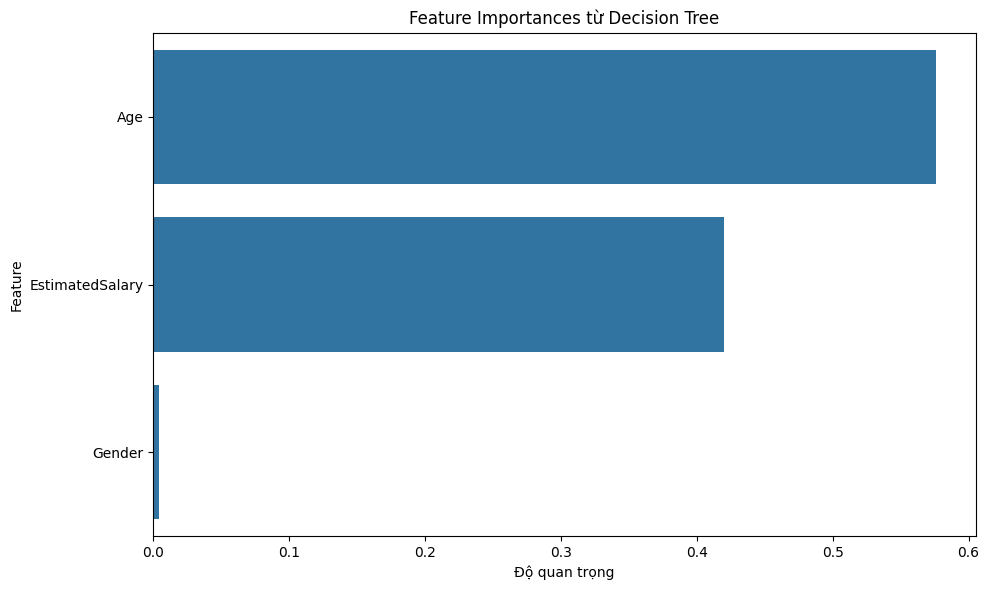

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo DataFrame chứa tên và độ quan trọng
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tree_model.feature_importances_
})

# Sắp xếp theo độ quan trọng giảm dần
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importances từ Decision Tree")
plt.xlabel("Độ quan trọng")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
np.unique(y_train)

array([0, 1])

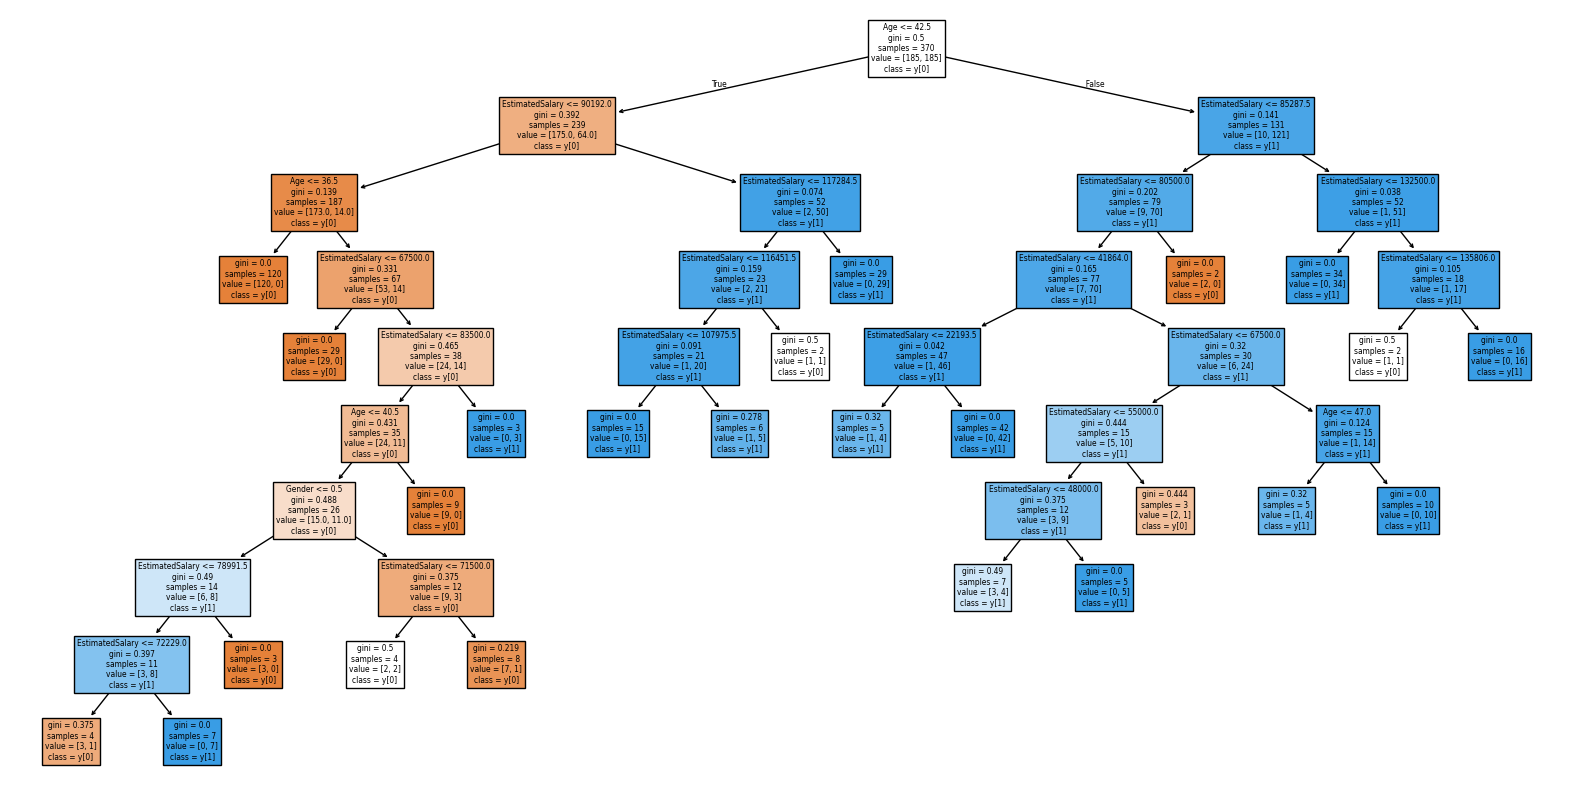

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=feature_names, class_names=True, filled=True)
plt.show()


#RF

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Tạo pipeline
pipe_rf = Pipeline(steps=[('rf', RandomForestClassifier(class_weight='balanced', criterion='entropy', max_depth=10, min_samples_leaf=1, min_samples_split=10, random_state=42))])

# Grid các hyperparameter quan trọng
"""    # Giống Decision Tree
    'rf__criterion': ['gini', 'entropy', 'log_loss'],  # Hàm đánh giá split
    'rf__max_depth': [None, 5, 10, 20],                # Độ sâu tối đa
    'rf__min_samples_split': [2, 5, 10],               # Min mẫu để split
    'rf__min_samples_leaf': [1, 2, 4],                 # Min mẫu ở leaf
    'rf__max_features': [None, 'sqrt', 'log2'],        # Số feature để split
    'rf__class_weight': [None, 'balanced'],            # Cân bằng lớp"""

param_grid_rf = {

    # Đặc trưng riêng của Random Forest
    'rf__n_estimators': [20, 50, 100, 200],                    # Số lượng cây
}



search_rf = GridSearchCV(pipe_rf, param_grid_rf, scoring='recall', cv=5, n_jobs=2)
search_rf.fit(X_train_oversampling, y_train_oversampling)

print("Best RF parameter (CV score=%.3f):" % search_rf.best_score_)
print(search_rf.best_params_)


from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
predicted_label = search_rf.predict(X_test)
print(classification_report(y_test, predicted_label, digits=3))

Best RF parameter (CV score=0.957):
{'rf__n_estimators': 50}
              precision    recall  f1-score   support

           0      0.951     0.812     0.876        48
           1      0.769     0.938     0.845        32

    accuracy                          0.863        80
   macro avg      0.860     0.875     0.861        80
weighted avg      0.878     0.863     0.864        80

